### Goal
We are going to build a dataset where:
* Each row = one match
* Features = player differences + cluster features
* Target = match outcome

We are going to split the data as the following:
* Train: 2018–2022
* Validation: 2023
* Test: 2024

#### Load Matches and Player Clusters

In [2]:
import pandas as pd

matches = pd.read_csv("../data/processed/matches_base.csv")
players = pd.read_csv("../data/processed/players_with_clusters.csv")

players = players[["player_id", "cluster"]]

print(matches.columns)
matches.head(2)


Index(['year', 'tourney_date', 'surface', 'tourney_level', 'winner_id',
       'winner_name', 'winner_rank', 'winner_age', 'winner_ht', 'loser_id',
       'loser_name', 'loser_rank', 'loser_age', 'loser_ht', 'w_ace', 'w_df',
       'w_bpSaved', 'w_bpFaced', 'l_ace', 'l_df', 'l_bpSaved', 'l_bpFaced'],
      dtype='object')


,year,tourney_date,surface,tourney_level,winner_id,winner_name,winner_rank,winner_age,winner_ht,loser_id,...,loser_age,loser_ht,w_ace,w_df,w_bpSaved,w_bpFaced,l_ace,l_df,l_bpSaved,l_bpFaced
0,2018,20180101,Hard,A,105992,Ryan Harrison,47.0,25.6,185.0,104919,...,30.6,188.0,9.0,2.0,8.0,9.0,10.0,3.0,1.0,4.0
1,2018,20180101,Hard,A,111577,Jared Donaldson,54.0,21.2,188.0,111442,...,23.7,183.0,5.0,3.0,4.0,5.0,3.0,5.0,7.0,11.0


#### Merge Cluster Labels into Matches

In [3]:
matches = matches.merge(players, left_on="winner_id", right_on="player_id", how="left")
matches = matches.rename(columns={"cluster": "winner_cluster"})

print(matches.columns)
matches.head()

Index(['year', 'tourney_date', 'surface', 'tourney_level', 'winner_id',
       'winner_name', 'winner_rank', 'winner_age', 'winner_ht', 'loser_id',
       'loser_name', 'loser_rank', 'loser_age', 'loser_ht', 'w_ace', 'w_df',
       'w_bpSaved', 'w_bpFaced', 'l_ace', 'l_df', 'l_bpSaved', 'l_bpFaced',
       'player_id', 'winner_cluster'],
      dtype='object')


,year,tourney_date,surface,tourney_level,winner_id,winner_name,winner_rank,winner_age,winner_ht,loser_id,...,w_ace,w_df,w_bpSaved,w_bpFaced,l_ace,l_df,l_bpSaved,l_bpFaced,player_id,winner_cluster
0,2018,20180101,Hard,A,105992,Ryan Harrison,47.0,25.6,185.0,104919,...,9.0,2.0,8.0,9.0,10.0,3.0,1.0,4.0,105992.0,4.0
1,2018,20180101,Hard,A,111577,Jared Donaldson,54.0,21.2,188.0,111442,...,5.0,3.0,4.0,5.0,3.0,5.0,7.0,11.0,111577.0,4.0
2,2018,20180101,Hard,A,104797,Denis Istomin,63.0,31.3,185.0,106000,...,7.0,0.0,9.0,11.0,8.0,6.0,10.0,16.0,104797.0,1.0
3,2018,20180101,Hard,A,200282,Alex De Minaur,208.0,18.8,183.0,105449,...,9.0,3.0,2.0,3.0,6.0,2.0,4.0,6.0,200282.0,0.0
4,2018,20180101,Hard,A,111581,Michael Mmoh,175.0,19.9,188.0,105643,...,5.0,4.0,3.0,3.0,4.0,0.0,0.0,2.0,111581.0,4.0


In [4]:
# We have to drop the player_id column as it is the same as winner_id now
matches = matches.drop(columns=["player_id"])

In [5]:
matches = matches.merge(players, left_on="loser_id", right_on="player_id", how="left")
matches = matches.rename(columns={"cluster": "loser_cluster"}).drop(columns=["player_id"])

matches.head()

,year,tourney_date,surface,tourney_level,winner_id,winner_name,winner_rank,winner_age,winner_ht,loser_id,...,w_ace,w_df,w_bpSaved,w_bpFaced,l_ace,l_df,l_bpSaved,l_bpFaced,winner_cluster,loser_cluster
0,2018,20180101,Hard,A,105992,Ryan Harrison,47.0,25.6,185.0,104919,...,9.0,2.0,8.0,9.0,10.0,3.0,1.0,4.0,4.0,4.0
1,2018,20180101,Hard,A,111577,Jared Donaldson,54.0,21.2,188.0,111442,...,5.0,3.0,4.0,5.0,3.0,5.0,7.0,11.0,4.0,3.0
2,2018,20180101,Hard,A,104797,Denis Istomin,63.0,31.3,185.0,106000,...,7.0,0.0,9.0,11.0,8.0,6.0,10.0,16.0,1.0,3.0
3,2018,20180101,Hard,A,200282,Alex De Minaur,208.0,18.8,183.0,105449,...,9.0,3.0,2.0,3.0,6.0,2.0,4.0,6.0,0.0,4.0
4,2018,20180101,Hard,A,111581,Michael Mmoh,175.0,19.9,188.0,105643,...,5.0,4.0,3.0,3.0,4.0,0.0,0.0,2.0,4.0,1.0


#### Missing Values

Some players won’t have clusters because they didn’t pass the MIN_MATCHES filter. We will handle this assigning cluster = -1 for unknown players.

In [6]:
matches["winner_cluster"] = matches["winner_cluster"].fillna(-1).astype(int)
matches["loser_cluster"] = matches["loser_cluster"].fillna(-1).astype(int)
matches.columns

Index(['year', 'tourney_date', 'surface', 'tourney_level', 'winner_id',
       'winner_name', 'winner_rank', 'winner_age', 'winner_ht', 'loser_id',
       'loser_name', 'loser_rank', 'loser_age', 'loser_ht', 'w_ace', 'w_df',
       'w_bpSaved', 'w_bpFaced', 'l_ace', 'l_df', 'l_bpSaved', 'l_bpFaced',
       'winner_cluster', 'loser_cluster'],
      dtype='object')

In [7]:
matches.to_csv("../Data/processed/matches_with_players_clusters.csv", index=False)

#### Build Match-Level Features

To avoid bias introduced by winner/loser columns, we transformed each match into two symmetric observations. This allows the model to learn relative differences between players rather than memorizing positional information.

In [9]:
import numpy as np

def build_match_dataset(matches):
    rows = []

    for _, row in matches.iterrows():
        # winner vs loser
        rows.append({
            "rank_diff": row["winner_rank"] - row["loser_rank"],
            "age_diff": row["winner_age"] - row["loser_age"],
            "height_diff": row["winner_ht"] - row["loser_ht"],
            "cluster_diff": row["winner_cluster"] - row["loser_cluster"],
            "surface": row["surface"],
            "tourney_level": row["tourney_level"],
            "target": 1
        })
        
        # loser vs winner
        rows.append({
            "rank_diff": row["loser_rank"] - row["winner_rank"],
            "age_diff": row["loser_age"] - row["winner_age"],
            "height_diff": row["loser_ht"] - row["winner_ht"],
            "cluster_diff": row["loser_cluster"] - row["winner_cluster"],
            "surface": row["surface"],
            "tourney_level": row["tourney_level"],
            "target": 0
        })
    
    return pd.DataFrame(rows)

dataset = build_match_dataset(matches)

print(dataset.shape)
dataset.head()


(37754, 7)


,rank_diff,age_diff,height_diff,cluster_diff,surface,tourney_level,target
0,-5.0,-5.0,-3.0,0,Hard,A,1
1,5.0,5.0,3.0,0,Hard,A,0
2,-40.0,-2.5,5.0,1,Hard,A,1
3,40.0,2.5,-5.0,-1,Hard,A,0
4,33.0,5.7,10.0,-2,Hard,A,1


Now we have the double of rows (37754 = 18877 * 2) because the build_match_dataset assigns two rows for each match, one from the winner perspective (target 1) and another from the loser perspective (target 0)

### Temporal Split

In [10]:
matches["year"].value_counts().sort_index()


year
2018    2897
2019    2806
2020    1462
2021    2733
2022    2917
2023    2986
2024    3076
Name: count, dtype: int64

In [11]:
train_matches = matches[matches["year"] <= 2022]
val_matches = matches[matches["year"] == 2023]
test_matches = matches[matches["year"] == 2024]

train_data = build_match_dataset(train_matches)
val_data = build_match_dataset(val_matches)
test_data = build_match_dataset(test_matches)

print(train_data.shape, val_data.shape, test_data.shape)

(25630, 7) (5972, 7) (6152, 7)


In [12]:
train_data.isna().sum()

rank_diff        354
age_diff           4
height_diff      340
cluster_diff       0
surface            0
tourney_level      0
target             0
dtype: int64

In [13]:
val_data.isna().sum()

rank_diff         92
age_diff           4
height_diff       80
cluster_diff       0
surface          106
tourney_level      0
target             0
dtype: int64

In [14]:
test_data.isna().sum()

rank_diff         92
age_diff           4
height_diff      120
cluster_diff       0
surface            0
tourney_level      0
target             0
dtype: int64

#### Summary
Train data
* rank_diff: 354 / 25,630 ≈ 1.38%
* height_diff: 340 / 25,630 ≈ 1.33%
* age_diff: 4 / 25,630 ≈ 0.02%

Validation data
* rank_diff: 92 / 5,972 ≈ 1.54%
* height_diff: 80 / 5,972 ≈ 1.34%
* surface: 106 / 5,972 ≈ 1.77%

Test data
* rank_diff: 92 / 6,152 ≈ 1.49%
* height_diff: 120 / 6,152 ≈ 1.95%

Rank_diff, height_diff, age_diff are numeric values, so we are going to choice the median imputation. The surface is a categorical value, so we are going to fill with most frequent surface. Hard courts dominate ATP tour, so it is a realistic assumption.

#### Imputation

In [15]:
from sklearn.impute import SimpleImputer

# Even though we don't have missing values in cluster_diff, we include it here for consistency
# The imputer does nothing to this column
numeric_features = ["rank_diff", "age_diff", "height_diff", "cluster_diff"]

num_imputer = SimpleImputer(strategy="median")

train_data[numeric_features] = num_imputer.fit_transform(train_data[numeric_features])
val_data[numeric_features] = num_imputer.transform(val_data[numeric_features])
test_data[numeric_features] = num_imputer.transform(test_data[numeric_features])


In [16]:
cat_imputer = SimpleImputer(strategy="most_frequent")

train_data[["surface"]] = cat_imputer.fit_transform(train_data[["surface"]])
val_data[["surface"]] = cat_imputer.transform(val_data[["surface"]])
test_data[["surface"]] = cat_imputer.transform(test_data[["surface"]])


In [17]:
print(train_data.isna().sum())
print(val_data.isna().sum())
print(test_data.isna().sum())


rank_diff        0
age_diff         0
height_diff      0
cluster_diff     0
surface          0
tourney_level    0
target           0
dtype: int64
rank_diff        0
age_diff         0
height_diff      0
cluster_diff     0
surface          0
tourney_level    0
target           0
dtype: int64
rank_diff        0
age_diff         0
height_diff      0
cluster_diff     0
surface          0
tourney_level    0
target           0
dtype: int64


In [18]:
# train_data.to_csv("../data/processed/train_matches.csv", index=False)
# val_data.to_csv("../data/processed/val_matches.csv", index=False)
# test_data.to_csv("../data/processed/test_matches.csv", index=False)

#### Encode Categorical Values
We transformed categorical match context variables using one-hot encoding, which increased the dimensionality of the feature space but allowed the model to capture surface and tournament level specific effects.

In [19]:
from sklearn.preprocessing import OneHotEncoder

categorical_features = ["surface", "tourney_level"]

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

X_train_cat = encoder.fit_transform(train_data[categorical_features])
X_val_cat = encoder.transform(val_data[categorical_features])
X_test_cat = encoder.transform(test_data[categorical_features])

In [20]:
import numpy as np

X_train_num = train_data[numeric_features].values
X_val_num = val_data[numeric_features].values
X_test_num = test_data[numeric_features].values




In [21]:
X_train = pd.DataFrame(np.hstack([X_train_num, X_train_cat]))
X_val = pd.DataFrame(np.hstack([X_val_num, X_val_cat]))
X_test = pd.DataFrame(np.hstack([X_test_num, X_test_cat]))

y_train = train_data["target"].values
y_val = val_data["target"].values
y_test = test_data["target"].values

print(X_train.shape, X_val.shape, X_test.shape)

(25630, 12) (5972, 12) (6152, 12)


In [22]:
X_train.head()

,0,1,2,3,4,5,6,7,8,9,10,11
0,-5.0,-5.0,-3.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
1,5.0,5.0,3.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
2,-40.0,-2.5,5.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
3,40.0,2.5,-5.0,-1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
4,33.0,5.7,10.0,-2.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0


#### Scale

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


In [24]:
# Get categorical feature names after one-hot encoding
cat_feature_names = encoder.get_feature_names_out(categorical_features)

# Combine numeric + categorical feature names
feature_names = numeric_features + list(cat_feature_names)

print("Total features:", len(feature_names))
print(feature_names)


Total features: 12
['rank_diff', 'age_diff', 'height_diff', 'cluster_diff', 'surface_Clay', 'surface_Grass', 'surface_Hard', 'tourney_level_A', 'tourney_level_D', 'tourney_level_F', 'tourney_level_G', 'tourney_level_M']


In [25]:
# Final datasets as DataFrames we will use for modeling

X_train_df = pd.DataFrame(X_train_scaled, columns=feature_names)
X_val_df = pd.DataFrame(X_val_scaled, columns=feature_names)
X_test_df = pd.DataFrame(X_test_scaled, columns=feature_names)

X_train_df

,rank_diff,age_diff,height_diff,cluster_diff,surface_Clay,surface_Grass,surface_Hard,tourney_level_A,tourney_level_D,tourney_level_F,tourney_level_G,tourney_level_M
0,-0.034700,-0.762719,-0.290623,0.000000,-0.647789,-0.335137,0.810669,0.89548,-0.267205,-0.091327,-0.481637,-0.471405
1,0.034700,0.762719,0.290623,0.000000,-0.647789,-0.335137,0.810669,0.89548,-0.267205,-0.091327,-0.481637,-0.471405
2,-0.277599,-0.381360,0.484371,0.434323,-0.647789,-0.335137,0.810669,0.89548,-0.267205,-0.091327,-0.481637,-0.471405
3,0.277599,0.381360,-0.484371,-0.434323,-0.647789,-0.335137,0.810669,0.89548,-0.267205,-0.091327,-0.481637,-0.471405
4,0.229019,0.869500,0.968743,-0.868645,-0.647789,-0.335137,0.810669,0.89548,-0.267205,-0.091327,-0.481637,-0.471405
...,...,...,...,...,...,...,...,...,...,...,...,...
25625,5.704649,1.464421,0.000000,0.000000,-0.647789,-0.335137,0.810669,-1.11672,3.742440,-0.091327,-0.481637,-0.471405
25626,0.000000,-0.610175,0.000000,0.000000,-0.647789,-0.335137,0.810669,-1.11672,3.742440,-0.091327,-0.481637,-0.471405
25627,0.000000,0.610175,0.000000,0.000000,-0.647789,-0.335137,0.810669,-1.11672,3.742440,-0.091327,-0.481637,-0.471405
25628,0.000000,-0.198307,0.000000,0.000000,-0.647789,-0.335137,0.810669,-1.11672,3.742440,-0.091327,-0.481637,-0.471405


## Train Logistic Regression (Baseline Model)

In [26]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_df, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


With log_reg.predict we obtain the class labes, 0 or 1 (in your case: loser wins / winner wins). Internally, logistic regression does this: computes the probability, applies a threshold (by default 0.5), and converts probability into class label (If probability ≥ 0.5 → predict 1; if probability < 0.5 → predict 0). With predict_proba we obtain the probability of each class ([ P(class=0), P(class=1) ]), (n, 2) shape matrix.


In [27]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

y_val_pred = log_reg.predict(X_val_scaled)
y_val_proba = log_reg.predict_proba(X_val_scaled)[:, 1]

acc_val = accuracy_score(y_val, y_val_pred)
auc_val = roc_auc_score(y_val, y_val_proba)

print(f"Validation Accuracy: {acc_val:.4f}")
print(f"Validation ROC-AUC: {auc_val:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_val, y_val_pred))

Validation Accuracy: 0.6088
Validation ROC-AUC: 0.6709

Classification Report:

              precision    recall  f1-score   support

           0       0.61      0.61      0.61      2986
           1       0.61      0.61      0.61      2986

    accuracy                           0.61      5972
   macro avg       0.61      0.61      0.61      5972
weighted avg       0.61      0.61      0.61      5972



c:\Users\X421IA\anaconda3\envs\spotify_py311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\X421IA\anaconda3\envs\spotify_py311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


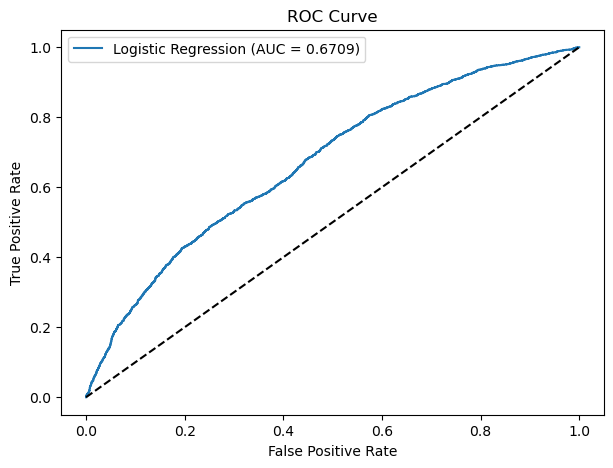

In [42]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_val, y_val_proba)

import matplotlib.pyplot as plt
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc_val:.4f})")
plt.plot([0, 1], [0, 1], "k--")  # Diagonal line for random guessing
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()



In [29]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, y_val_pred)
print(cm)

[[1819 1167]
 [1169 1817]]


### Model Performance Interpretation
* Validation Accuracy: 0.6088. The model predicts the winner correctly about 61% of the time
* ROC-AUC: 0.6709, that is a solid predictive power.
* Precision = 0.61, recall = 0.61, f1-score  = 0.61 means no bias toward predicting winners or losers, dataset is balanced and the model is stable.



The model is learning (ranking differences matter, player physical/contextual attributes matter, surface & tournament context matter, player style clusters likely add signal)

### Experiment: Does Player Clustering Help Prediction?

Does including cluster_diff improve predictive performance? 
Let's train Model without cluster_diff

In [30]:
features_no_cluster = [f for f in feature_names if "cluster_diff" not in f]
features_no_cluster

['rank_diff',
 'age_diff',
 'height_diff',
 'surface_Clay',
 'surface_Grass',
 'surface_Hard',
 'tourney_level_A',
 'tourney_level_D',
 'tourney_level_F',
 'tourney_level_G',
 'tourney_level_M']

In [31]:
X_train_no_cluster = X_train_df[features_no_cluster]
X_val_no_cluster = X_val_df[features_no_cluster]


In [32]:
log_reg_no_cluster = LogisticRegression(max_iter=1000, random_state=42)
log_reg_no_cluster.fit(X_train_no_cluster, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [33]:
y_val_pred_no_cluster = log_reg_no_cluster.predict(X_val_no_cluster)
y_val_proba_no_cluster = log_reg_no_cluster.predict_proba(X_val_no_cluster)[:, 1]

acc_nc = accuracy_score(y_val, y_val_pred_no_cluster)
auc_nc = roc_auc_score(y_val, y_val_proba_no_cluster)

print(f"Validation Accuracy (no cluster): {acc_nc:.4f}")
print(f"Validation ROC-AUC (no cluster): {auc_nc:.4f}")


Validation Accuracy (no cluster): 0.6186
Validation ROC-AUC (no cluster): 0.6697


#### Results Comparison

| Model             | Accuracy   | ROC-AUC    |
| ----------------- | ---------- | ---------- |
| ✅ With cluster    | **0.6088** | **0.6709** |
| ❌ Without cluster | **0.6186** | **0.6697** |


Accuracy improved without cluster (+0.0098 ≈ +1%), ROC-AUC slightly worsened without cluster (-0.0012). Nevertheless, these differences are very small

#### Interpretation
Your clustering captures:
* Player tactical style differences
* But match outcome is still dominated by: ranking differences, physical differences, contextual match factors

Player style clustering provides marginal predictive signal but does not significantly improve classification performance, suggesting that match outcomes are primarily influenced by ranking and contextual features rather than stylistic similarity alone. However,  we are going to mantain it because it lightly improves ROC-AUC, which is actually more important than accuracy in sports prediction.

### Model Interpretation: Which features most influence match outcomes?

In [34]:
print(log_reg.intercept_)
print(log_reg.coef_)
log_reg.coef_[0]

[-1.01450073e-17]
[[-7.55683743e-01 -5.53356899e-02  1.22418311e-01 -2.08067151e-01
   3.43569581e-18  1.48795783e-18 -1.12935358e-18  1.72527741e-18
  -1.07859954e-18 -2.47615039e-18 -9.10396289e-19 -3.73066605e-19]]


array([-7.55683743e-01, -5.53356899e-02,  1.22418311e-01, -2.08067151e-01,
        3.43569581e-18,  1.48795783e-18, -1.12935358e-18,  1.72527741e-18,
       -1.07859954e-18, -2.47615039e-18, -9.10396289e-19, -3.73066605e-19])

In [35]:
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": log_reg.coef_[0]
})

coef_df["abs_coef"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("abs_coef", ascending=False)

coef_df

,feature,coefficient,abs_coef
0,rank_diff,-7.556837e-01,7.556837e-01
3,cluster_diff,-2.080672e-01,2.080672e-01
2,height_diff,1.224183e-01,1.224183e-01
1,age_diff,-5.533569e-02,5.533569e-02
4,surface_Clay,3.435696e-18,3.435696e-18
9,tourney_level_F,-2.476150e-18,2.476150e-18
7,tourney_level_A,1.725277e-18,1.725277e-18
5,surface_Grass,1.487958e-18,1.487958e-18
6,surface_Hard,-1.129354e-18,1.129354e-18
8,tourney_level_D,-1.078600e-18,1.078600e-18


| Feature         | Importance |
| --------------- | ---------- |
| 🥇 rank_diff    | 0.756      |
| 🥈 cluster_diff | 0.208      |
| 🥉 height_diff  | 0.122      |
| age_diff        | 0.055      |


* Rank difference dominates; it is the strongest predictor
* Cluster Difference is second strongest; player style/tactical grouping contains meaningful information beyond ranking
* Height and Age Effects smaller but believable; taller players have serve advantage and older players dcline in performance

#### Surface Interpretation
The surprisng insight here is that surface effects are near zero, which is quite rare as surface usually plays a crucial role in a match outcome (there are surface specialist players). This fact might tells us something about the dataset we used; let's explore:
* Rank already captures surface ability indirectly. Top players usually perform well across surfaces. Ranking already contains historical surface performance, so surface adds little new information. This is very plausible.
* Surface effect might be player-specific, not global (Nadal is a clay specialist, Federer a grass specialist, etc). The model uses global surface effect, not player-surface interaction, so surface alone appears weak.
* My feature is "surface of match", not "player surface win rate", which would be a much stronger feature.

### Evaluate Final Model on Test Set

In [36]:
y_test_pred = log_reg.predict(X_test_df)
y_test_proba = log_reg.predict_proba(X_test_df)[:, 1]

test_acc = accuracy_score(y_test, y_test_pred)
test_auc = roc_auc_score(y_test, y_test_proba)

print(f"Test Accuracy (2024): {test_acc:.4f}")
print(f"Test ROC-AUC (2024): {test_auc:.4f}")

print("\nTest Classification Report:\n")
print(classification_report(y_test, y_test_pred))

Test Accuracy (2024): 0.6177
Test ROC-AUC (2024): 0.6697

Test Classification Report:

              precision    recall  f1-score   support

           0       0.62      0.62      0.62      3076
           1       0.62      0.62      0.62      3076

    accuracy                           0.62      6152
   macro avg       0.62      0.62      0.62      6152
weighted avg       0.62      0.62      0.62      6152



#### Results

| Metric   | Validation (2023) | Test (2024) |
| -------- | ----------------- | ----------- |
| Accuracy | 0.6088            | **0.6177**  |
| ROC-AUC  | 0.6709            | **0.6697**  |


* Your test ROC-AUC is basically identical to validation (no overfitting, stable feature relationships, eobust modeling choices)
* Accuracy increased slightly on 2024 (maybe 2024 distribution slightly different)
* Class Balance Is Perfect (3076 vs 3076)

Developed a tennis match outcome prediction system evaluated on future season data, achieving ROC-AUC ≈ 0.67 on unseen matches

#### Scientific Summary for Readme
* Ranking differences are the strongest predictor of match outcomes.
* Player style clustering adds secondary predictive signal.
* Physical attributes (height, age) provide modest improvements.
* Global surface effects are limited without player-specific modeling.
* Model generalizes well across seasons (2018–2024).

#### Save Data for the next file

In [37]:
X_train_df.to_csv("../data/processed/X_train.csv", index=False)
X_val_df.to_csv("../data/processed/X_val.csv", index=False)
X_test_df.to_csv("../data/processed/X_test.csv", index=False)


In [38]:
pd.Series(y_train).to_csv("../data/processed/y_train.csv", index=False)
pd.Series(y_val).to_csv("../data/processed/y_val.csv", index=False)
pd.Series(y_test).to_csv("../data/processed/y_test.csv", index=False)


In [39]:
pd.Series(feature_names).to_csv("../data/processed/feature_names.csv", index=False)
